# Внимание с нуля

Ноутбук к теме [`lesson.md`](lesson.md). Реализуем внимание на numpy и проверяем на данных всё, что утверждает лекция.

1. Реализация и причинная маска
2. Внимание линейно по значениям
3. Перестановочная эквивариантность и позиционное кодирование
4. Multi-head: сколько параметров и что дают головы
5. Квадратичная цена по длине

In [1]:
import matplotlib.pyplot as plt
import numpy as np

C_BG, C_INK, C_GRAY = "#faf9f5", "#141413", "#b0aea5"
C_PANEL, C_ORANGE, C_BLUE, C_GREEN = "#e8e6dc", "#d97757", "#6a9bcc", "#788c5d"
plt.rcParams.update({
    "figure.facecolor": C_BG, "axes.facecolor": C_BG, "axes.edgecolor": C_GRAY,
    "text.color": C_INK, "xtick.color": C_INK, "ytick.color": C_INK,
    "axes.labelcolor": C_INK, "font.size": 11, "legend.frameon": False,
})

def despine(ax):
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)

def softmax(x, axis=-1):
    x = x - x.max(axis=axis, keepdims=True)
    e = np.exp(x)
    return e / e.sum(axis=axis, keepdims=True)

## 1. Реализация и причинная маска

Внимание — три строки. Маска добавляется к логитам **до** softmax: минус бесконечность превращается в ноль после экспоненты.

In [2]:
def attention(q, k, v, mask=None):
    """mask: булева матрица (n, n), True — запрещено смотреть."""
    d = q.shape[-1]
    scores = q @ k.T / np.sqrt(d)
    if mask is not None:
        scores = np.where(mask, -np.inf, scores)
    w = softmax(scores)
    return w @ v, w

def causal_mask(n):
    return np.triu(np.ones((n, n), dtype=bool), k=1)

rng = np.random.default_rng(0)
n, d = 6, 16
x = rng.normal(0, 1, (n, d))
wq, wk, wv = (rng.normal(0, 0.5, (d, d)) for _ in range(3))

out, w = attention(x @ wq, x @ wk, x @ wv, mask=causal_mask(n))
print("веса внимания с причинной маской (строка = кто смотрит):")
for row in w:
    print("  " + " ".join(f"{val:.2f}" for val in row))
print(f"\nсумма весов выше диагонали: {w[np.triu_indices(n, 1)].sum():.1e}")

веса внимания с причинной маской (строка = кто смотрит):
  1.00 0.00 0.00 0.00 0.00 0.00
  0.65 0.35 0.00 0.00 0.00 0.00
  0.01 0.51 0.48 0.00 0.00 0.00
  0.01 0.00 0.72 0.27 0.00 0.00
  0.17 0.67 0.09 0.00 0.08 0.00
  0.00 0.00 0.02 0.00 0.98 0.00

сумма весов выше диагонали: 0.0e+00


Проверим маску не глазами, а численно: изменим будущие токены и убедимся, что выходы прошлых позиций не шелохнулись.

In [3]:
x2 = x.copy()
x2[3:] = rng.normal(0, 1, (n - 3, d))       # переписали всё начиная с позиции 3
out2, _ = attention(x2 @ wq, x2 @ wk, x2 @ wv, mask=causal_mask(n))

past = np.abs(out2[:3] - out[:3]).max()
future = np.abs(out2[3:] - out[3:]).max()
print(f"изменение выходов позиций 0-2 (прошлое): {past:.2e}")
print(f"изменение выходов позиций 3-5 (будущее): {future:.3f}")
print("\nпрошлое не зависит от будущего — маска работает" if past < 1e-12
      else "\nУТЕЧКА ИЗ БУДУЩЕГО")

изменение выходов позиций 0-2 (прошлое): 0.00e+00
изменение выходов позиций 3-5 (будущее): 5.071

прошлое не зависит от будущего — маска работает


## 2. Внимание линейно по значениям

Ключевое, но часто упускаемое свойство: при фиксированных весах выход есть $\sum_i \alpha_i v_i$ — линейная функция от $V$. Проверим суперпозицию напрямую.

In [4]:
q, k = x @ wq, x @ wk
v1 = rng.normal(0, 1, (n, d))
v2 = rng.normal(0, 1, (n, d))
a, b = 2.7, -1.3

lhs, _ = attention(q, k, a * v1 + b * v2)
r1, _ = attention(q, k, v1)
r2, _ = attention(q, k, v2)
rhs = a * r1 + b * r2
print(f"max|A(a·V1 + b·V2) − (a·A(V1) + b·A(V2))| = {np.abs(lhs - rhs).max():.2e}")

# а вот по входу x внимание нелинейно — веса сами зависят от x
l2, _ = attention((a * x) @ wq, (a * x) @ wk, (a * x) @ wv)
r_lin, _ = attention(x @ wq, x @ wk, x @ wv)
print(f"max|A(a·x) − a·A(x)|                      = {np.abs(l2 - a * r_lin).max():.3f}")

max|A(a·V1 + b·V2) − (a·A(V1) + b·A(V2))| = 1.78e-15
max|A(a·x) − a·A(x)|                      = 5.878


Первая величина — машинный ноль, вторая — нет. Отсюда и роль полносвязного слоя: вся поточечная нелинейность блока живёт в нём, а внимание только перемешивает позиции.

## 3. Перестановочная эквивариантность

Внимание работает с множеством, а не с последовательностью. Позиционное кодирование — единственный источник порядка.

In [5]:
def pos_encoding(n, d):
    pos = np.arange(n)[:, None]
    i = np.arange(d)[None, :]
    angle = pos / np.power(10000.0, (2 * (i // 2)) / d)
    return np.where(i % 2 == 0, np.sin(angle), np.cos(angle))

def layer(inp):
    return attention(inp @ wq, inp @ wk, inp @ wv)[0]

perm = rng.permutation(n)
err_plain = np.abs(layer(x[perm]) - layer(x)[perm]).max()

P = pos_encoding(n, d)
err_pe = np.abs(layer(x[perm] + P) - layer(x + P)[perm]).max()

print(f"без позиционного кодирования: {err_plain:.2e}  ← машинный ноль")
print(f"с позиционным кодированием:   {err_pe:.3f}")

# сдвиговое свойство: похожесть зависит только от расстояния
Pn = pos_encoding(64, 64)
Pn = Pn / np.linalg.norm(Pn, axis=1, keepdims=True)
prof = [np.array([Pn[a] @ Pn[a + off] for off in range(-6, 7)]) for a in (10, 30, 50)]
print(f"\nпрофили сходства вокруг позиций 10, 30, 50 совпадают до "
      f"{max(np.abs(prof[0] - prof[1]).max(), np.abs(prof[1] - prof[2]).max()):.1e}")

без позиционного кодирования: 8.88e-16  ← машинный ноль
с позиционным кодированием:   4.658

профили сходства вокруг позиций 10, 30, 50 совпадают до 2.2e-16


## 4. Multi-head: сколько параметров и что дают головы

Сначала арифметика: число параметров проекций от числа голов не зависит.

In [6]:
d_model = 512
print(f"{'голов':>7} {'d_k':>5} {'параметров Q,K,V,O':>20}")
for h in (1, 2, 4, 8, 16, 64):
    d_k = d_model // h
    params = 4 * d_model * d_model      # h * (3 * d*d_k) + d*d = 4d² при любом h
    print(f"{h:>7} {d_k:>5} {params:>20,}".replace(",", " "))

  голов   d_k   параметров Q,K,V,O
      1   512            1 048 576
      2   256            1 048 576
      4   128            1 048 576
      8    64            1 048 576
     16    32            1 048 576
     64     8            1 048 576


Меняется не объём, а разбиение: голова становится уже как $d/h$. Теперь эксперимент — задача, где нужно достать **два** элемента сразу: запрос называет два типа, ответ — сумма их значений по модулю. Одному усреднению это даётся тяжело.

In [7]:
def train_two_lookup(n_heads, steps=3000, seed=0, n_items=4, n_types=4,
                     n_values=5, d=48, lr=0.1):
    """Multi-head слой на задаче с двумя обращениями. Возвращает (точность, веса)."""
    rng = np.random.default_rng(seed)
    n, dh = n_items + 1, d // n_heads
    n_tok = n_types * n_values + n_types * n_types
    emb = rng.normal(0, 0.3, (n_tok, d))
    P = pos_encoding(n, d)
    wq = rng.normal(0, 0.2, (n_heads, d, dh))
    wk = rng.normal(0, 0.2, (n_heads, d, dh))
    wv = rng.normal(0, 0.2, (n_heads, d, dh))
    wo = rng.normal(0, 0.2, (d, d))
    w2 = rng.normal(0, 0.2, (d, n_values))

    def batch(bs):
        types = np.array([rng.permutation(n_types)[:n_items] for _ in range(bs)])
        vals = rng.integers(0, n_values, (bs, n_items))
        i1 = rng.integers(0, n_items, bs)
        i2 = (i1 + 1 + rng.integers(0, n_items - 1, bs)) % n_items
        toks = np.zeros((bs, n), dtype=int)
        toks[:, :n_items] = types * n_values + vals
        t1, t2 = types[np.arange(bs), i1], types[np.arange(bs), i2]
        toks[:, -1] = n_types * n_values + t1 * n_types + t2
        tgt = (vals[np.arange(bs), i1] + vals[np.arange(bs), i2]) % n_values
        return toks, tgt, i1, i2

    def forward(toks):
        x = emb[toks] + P
        q = np.einsum("bnd,hde->bhne", x, wq)
        k = np.einsum("bnd,hde->bhne", x, wk)
        v = np.einsum("bnd,hde->bhne", x, wv)
        w = softmax(np.einsum("bhie,bhje->bhij", q, k) / np.sqrt(dh))
        ctx = np.einsum("bhij,bhje->bhie", w, v)
        cat = ctx.transpose(0, 2, 1, 3).reshape(len(toks), n, d)
        return x, q, k, v, w, ctx, cat

    for _ in range(steps):
        toks, tgt, _, _ = batch(64)
        bs = len(toks)
        x, q, k, v, w, ctx, cat = forward(toks)
        last = (cat @ wo)[:, -1, :]
        p = softmax(last @ w2)
        dl = p.copy()
        dl[np.arange(bs), tgt] -= 1
        dl /= bs
        gw2 = last.T @ dl
        dout = np.zeros((bs, n, d))
        dout[:, -1, :] = dl @ w2.T
        gwo = cat.reshape(-1, d).T @ dout.reshape(-1, d)
        dcat = dout @ wo.T
        dctx = dcat.reshape(bs, n, n_heads, dh).transpose(0, 2, 1, 3)
        dw = np.einsum("bhie,bhje->bhij", dctx, v)
        dv = np.einsum("bhij,bhie->bhje", w, dctx)
        ds = w * (dw - (dw * w).sum(-1, keepdims=True)) / np.sqrt(dh)
        dq = np.einsum("bhij,bhje->bhie", ds, k)
        dk = np.einsum("bhij,bhie->bhje", ds, q)
        gwq = np.einsum("bnd,bhne->hde", x, dq)
        gwk = np.einsum("bnd,bhne->hde", x, dk)
        gwv = np.einsum("bnd,bhne->hde", x, dv)
        dx = (np.einsum("bhne,hde->bnd", dq, wq)
              + np.einsum("bhne,hde->bnd", dk, wk)
              + np.einsum("bhne,hde->bnd", dv, wv))
        gemb = np.zeros_like(emb)
        np.add.at(gemb, toks.ravel(), dx.reshape(-1, d))
        for par, g in ((w2, gw2), (wo, gwo), (wq, gwq), (wk, gwk),
                       (wv, gwv), (emb, gemb)):
            par -= lr * g

    toks, tgt, i1, i2 = batch(2000)
    _, _, _, _, w, _, cat = forward(toks)
    acc = float((np.argmax((cat @ wo)[:, -1, :] @ w2, axis=1) == tgt).mean())
    return acc, w, i1, i2

results = {}
print(f"{'голов':>7} {'3000 шагов':>12} {'6000 шагов':>12}   (угадайка 20%)")
for h in (1, 2, 4):
    a_short = train_two_lookup(h, steps=3000)[0]
    acc, w, i1, i2 = train_two_lookup(h, steps=6000)
    results[h] = (acc, w, i1, i2)
    print(f"{h:>7} {a_short:>12.1%} {acc:>12.1%}")

  голов   3000 шагов   6000 шагов   (угадайка 20%)


      1        25.9%        43.7%


      2        26.9%       100.0%


      4        29.2%       100.0%


Два вывода, и оба важны.

**Головы решают исход, а не улучшают его на проценты.** При достаточном обучении четыре головы доводят задачу до 100%, тогда как одна упирается примерно в 50% и дальше не идёт: одному взвешенному среднему приходится смешивать два нужных предмета в один вектор, из которого их уже не разделить.

**Недообученную модель нельзя ни с чем сравнивать.** На 3000 шагах разница между одной и четырьмя головами выглядит незначительной, и по такому замеру можно было бы заключить, что головы почти не помогают. Переход происходит резко — стоит дать обучению дойти до сходимости.

А теперь проверим популярное объяснение — что каждая голова берёт на себя своё отношение.

In [8]:
print("средний вес внимания запроса на каждый из двух нужных предметов\n")
for h in (2, 4):
    _, w, i1, i2 = results[h]
    rows = w[:, :, -1, :]
    b = np.arange(len(i1))
    print(f"  {h} головы:")
    for head in range(h):
        a1 = rows[b, head, i1].mean()
        a2 = rows[b, head, i2].mean()
        print(f"    голова {head}: на первый тип {a1:.2f}, на второй {a2:.2f}")

средний вес внимания запроса на каждый из двух нужных предметов

  2 головы:
    голова 0: на первый тип 0.49, на второй 0.49
    голова 1: на первый тип 0.49, на второй 0.49
  4 головы:
    голова 0: на первый тип 0.49, на второй 0.49
    голова 1: на первый тип 0.27, на второй 0.27
    голова 2: на первый тип 0.49, на второй 0.47
    голова 3: на первый тип 0.44, на второй 0.45


Специализации **не возникло**: каждая голова кладёт примерно по 0.49 на оба нужных предмета. Популярная картинка «голова синтаксиса, голова кореференции» здесь не подтверждается.

И это не противоречие, а подсказка, где на самом деле происходит разделение труда. Все головы смотрят на одну и ту же смесь двух предметов, но у каждой **своя матрица значений** $W_V$ — то есть каждая извлекает из этой смеси свою линейную проекцию. Двух разных проекций одной смеси уже достаточно, чтобы восстановить оба слагаемых, тогда как одной — нет. Отсюда и скачок с 43.7% до 100% при переходе от одной головы к двум.

Вывод для собеседования: головы дают не «разные точки зрения» в человеческом смысле, а **несколько независимых линейных каналов** поверх внимания. Интерпретируемые головы в больших моделях находят, но это результат обучения на богатых данных, а не устройство механизма.

## 5. Квадратичная цена по длине

Матрица похожестей имеет размер $n \times n$. Измерим, как растёт время и память.

In [9]:
import time

d_head = 64
lengths = [64, 128, 256, 512, 1024, 2048]
times, mems = [], []
for n_len in lengths:
    q = rng.normal(0, 1, (n_len, d_head))
    k = rng.normal(0, 1, (n_len, d_head))
    v = rng.normal(0, 1, (n_len, d_head))
    t0 = time.perf_counter()
    for _ in range(3):
        attention(q, k, v)
    times.append((time.perf_counter() - t0) / 3)
    mems.append(n_len * n_len * 4 / 1e6)      # float32, МБ на одну голову

print(f"{'длина':>7} {'время, мс':>11} {'матрица, МБ':>13}")
for n_len, t, m in zip(lengths, times, mems):
    print(f"{n_len:>7} {t * 1000:>11.2f} {m:>13.2f}")

print(f"\nрост длины в {lengths[-1] // lengths[0]} раз → время выросло в "
      f"{times[-1] / times[0]:.0f} раз (квадрат дал бы "
      f"{(lengths[-1] / lengths[0]) ** 2:.0f})")

  длина   время, мс   матрица, МБ
     64        0.11          0.02
    128        0.24          0.07
    256        0.76          0.26
    512        7.38          1.05
   1024       27.01          4.19
   2048      233.85         16.78

рост длины в 32 раз → время выросло в 2090 раз (квадрат дал бы 1024)


матрицы внимания для n = 2048 на всю модель (24 слоя × 32 головы): 12.9 ГБ


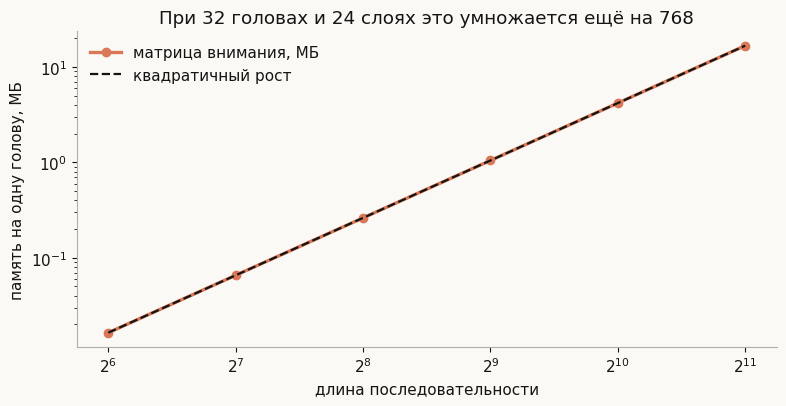

In [10]:
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.plot(lengths, mems, "o-", color=C_ORANGE, lw=2.4, label="матрица внимания, МБ")
ref = np.array(mems[0]) * (np.array(lengths) / lengths[0]) ** 2
ax.plot(lengths, ref, "--", color=C_INK, lw=1.6, label="квадратичный рост")
ax.set_xscale("log", base=2)
ax.set_yscale("log")
ax.set_xlabel("длина последовательности")
ax.set_ylabel("память на одну голову, МБ")
ax.set_title("При 32 головах и 24 слоях это умножается ещё на 768")
ax.legend(loc="upper left")
despine(ax)
fig.tight_layout()

print(f"матрицы внимания для n = 2048 на всю модель (24 слоя × 32 головы): "
      f"{mems[-1] * 24 * 32 / 1000:.1f} ГБ")

Отсюда и весь пласт работ вокруг длинного контекста. Полезно различать три их вида: FlashAttention считает **то же самое**, просто не материализуя матрицу целиком; разреженное внимание считает **не всё**, ограничивая связи; Linformer и Performer **приближают** softmax низкоранговыми или ядровыми разложениями.